In [24]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, Dropout, LSTM, Conv1D, MaxPooling1D, Flatten
import scipy.io
from sklearn.model_selection import train_test_split

In [25]:
# # get variable names
# var_names = scipy.io.whosmat('tensor4D.mat')

# # get data matrix from mat file
# mat_file = scipy.io.loadmat('tensor4D.mat')
# data_matrix = mat_file[var_names[0][0]]

# # convert to numpy array
# numpy_array = np.array(data_matrix)

# # print shape of numpy array
# print(numpy_array.shape)

# # save numpy array to file
# np.save('tensor4D.npy', numpy_array)

import numpy as np
# Load the input data previously saved as npy
values = np.load("tensor4D.npy")# import numpy as np

In [26]:
import numpy as np

# Suppose your original data has shape (24, lat_size, lon_size, feat_size)
# where lat_size is the number of latitude grid points, lon_size is the number of longitude grid points,
# and feat_size is the number of features
lat_size=values.shape[1]
lon_size= values.shape[2]
feat_size= values.shape[3]
samples = values.shape[0]

step = 1
step_size=1095

# Compute the reduced data by averaging every 6 hours
reduced_data = np.zeros((step_size, lat_size, lon_size, feat_size))
for i in range(step_size):
    reduced_data[i] = np.mean(values[i*step:(i+1)*step], axis=0)

# To verify that the reduced data is correct, you can print out the shape
print(reduced_data.shape)
values=reduced_data
values = np.nan_to_num(values, nan=0)
del reduced_data

(1095, 53, 68, 9)


In [27]:
# values= values[:800,:]
# values.shape

scaled_data=values
del values

# Split data into train, test and val sets
train, test = train_test_split(scaled_data, test_size=0.2, shuffle=False)
train, val = train_test_split(train, test_size=0.1, shuffle=False)

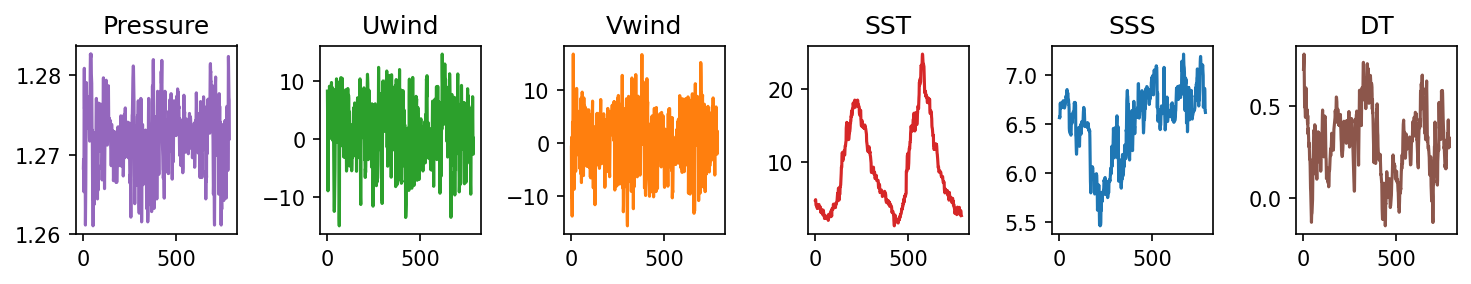

In [28]:
import matplotlib.pyplot as plt

# test.shape
# plt.plot(train[:,20,32,0])

# plt.plot(train[0,:,:,0])
x1=train.shape[0]
a=len(train)
x = np.linspace(0, a,x1)

i=20
j=20


fig, axs = plt.subplots(1,6,figsize=(10, 2), dpi=150)
# axs[0].plot(x, train[:,i,j,0],'tab:pink')
# axs[0].set_title("dist")
# axs[0].text(23.5, 65.85,  f"{i}, {j}", fontsize=8, color='red')
axs[0].plot(x, train[:,i,j,3],'tab:purple')
axs[0].set_title("Pressure")
axs[1].plot(x, train[:,i,j,4],'tab:green')
axs[1].set_title("Uwind")
axs[2].plot(x, train[:,i,j,5],'tab:orange')
axs[2].set_title("Vwind")
axs[3].plot(x, train[:,i,j,6],'tab:red')
axs[3].set_title("SST")
axs[4].plot(x, train[:,i,j,7],'tab:blue')
axs[4].set_title("SSS")
axs[5].plot(x, train[:,i,j,8],'tab:brown')
axs[5].set_title("DT")
fig.tight_layout()

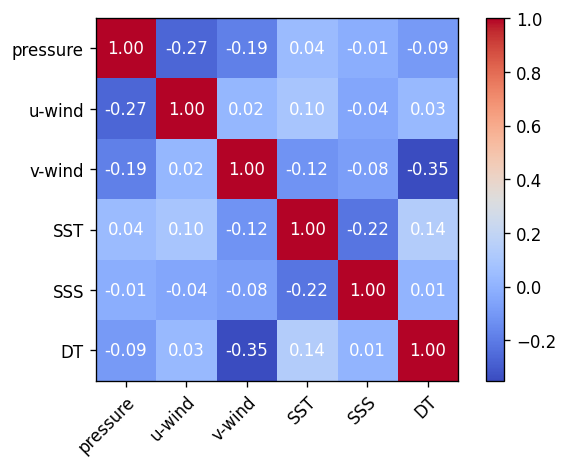

In [22]:
import numpy as np
# import seaborn as sns
import matplotlib.pyplot as plt

# create a random array with 5 features
array = train[:,i,j,3:]

# calculate the correlation matrix
corr_matrix = np.corrcoef(array, rowvar=False)

# calculate the correlation matrix
corr_matrix = np.corrcoef(array, rowvar=False)

# create a figure and axes
fig, ax = plt.subplots(dpi=120)

# create the heatmap
heatmap = ax.imshow(corr_matrix, cmap='coolwarm')

# add a colorbar
cbar = ax.figure.colorbar(heatmap, ax=ax)

# set the x and y axis labels
features = ('pressure', 'u-wind', 'v-wind', 'SST', 'SSS', 'DT')
ax.set_xticks(np.arange(len(features)))
ax.set_yticks(np.arange(len(features)))
ax.set_xticklabels(features)
ax.set_yticklabels(features)

# rotate the x axis labels
plt.setp(ax.get_xticklabels(), rotation=45, ha="right",
         rotation_mode="anchor")

# add annotations
for i in range(len(features)):
    for j in range(len(features)):
        text = ax.text(j, i, f"{corr_matrix[i, j]:.2f}",
                       ha="center", va="center", color="w")

# show the plot
plt.show()


In [9]:
# Compute the minimum and maximum values for each channel of the training set
train_min = np.min(train, axis=(0, 1, 2))
train_max = np.max(train, axis=(0, 1, 2))

# Normalize the training data using the minimum and maximum values from the training set
for i in range(train.shape[3]):
    train[:, :, :, i] = (train[:, :, :, i] - train_min[i]) / (train_max[i] - train_min[i])

# Normalize the test data using the minimum and maximum values from the training set
for i in range(test.shape[3]):
    test[:, :, :, i] = (test[:, :, :, i] - train_min[i]) / (train_max[i] - train_min[i])

# Normalize the validation data using the minimum and maximum values from the training set
for i in range(val.shape[3]):
    val[:, :, :, i] = (val[:, :, :, i] - train_min[i]) / (train_max[i] - train_min[i])

In [10]:
data=scaled_data
data.shape
window_size= 10
horizons=[1,2,3,4,5]
# Calculate the number of samples
n_samples = data.shape[0]
num_samples, lat_grid, long_grid, num_features = data.shape  
import numpy as np

def create_time_windows(data, window_size, horizons):
    """
    Creates time windows for a multistep ahead CNN-LSTM model.
    
    Args:
        data (numpy.ndarray): 4D tensor of shape (num_samples, lat_grid, long_grid, num_features)
        window_size (int): size of the sliding window
        horizons (list): list of horizons to predict
        
    Returns:
        Tuple of X and y where X is a numpy array of input windows of shape
        (num_windows, window_size, lat_grid, long_grid, num_features) and
        y is a numpy array of target windows of shape
        (num_windows, len(horizons), lat_grid, long_grid, num_features)
    """
    num_samples, lat_grid, long_grid, num_features = data.shape
    num_windows = num_samples - window_size - max(horizons) + 1
    X = np.zeros((num_windows, window_size, lat_grid, long_grid, num_features))
    y = np.zeros((num_windows, len(horizons), lat_grid, long_grid, num_features))
    for i in range(num_windows):
        for j, h in enumerate(horizons):
            y[i,j] = data[i+h:i+h+1,:,:,:]
        X[i] = data[i:i+window_size,:,:,:]
    return X, y

In [11]:
trainX, trainY= create_time_windows(train,window_size,horizons)
testX, testY= create_time_windows(test,window_size,horizons)
valX, valY= create_time_windows(val,window_size,horizons)

In [12]:
# Define model architecture
look_back = window_size
look_forward = max(horizons)
n_steps=look_forward
lat=scaled_data.shape[1]
lon=scaled_data.shape[2]


num_samples, lat_grid, long_grid, num_features = scaled_data.shape

# Define model parameters
n_timesteps = look_back# Number of timesteps
n_features = num_features# Number of features
n_lat = lat_grid# Number of latitude points
n_lon = long_grid# Number of longitude points


y_train=trainY[:,:,:,:,-1]
y_test=testY[:,:,:,:,-1]
y_val=valY[:,:,:,:,-1]
# y_train.shape

del scaled_data

In [12]:
## attention based convlstm

import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, ConvLSTM2D, Flatten, Dense, Reshape, Permute, Multiply, Lambda, Softmax, Dropout
from tensorflow.keras.models import Model

epochs=100
# Define input shape
input_shape = (n_timesteps, n_lat, n_lon, n_features)

# Define the CNN-LSTM model architecture with attention
inputs = Input(shape=input_shape)
conv = ConvLSTM2D(filters=32, kernel_size=(3, 3), padding='same', return_sequences=True)(inputs)
conv = Dropout(rate=0.2)(conv) # Add a dropout layer here
# conv = ConvLSTM2D(filters=64, kernel_size=(3, 3), padding='same', return_sequences=True)(conv)
# conv = ConvLSTM2D(filters=64, kernel_size=(3, 3), padding='same', return_sequences=True)(conv)

# Implement the attention mechanism
attention = Conv2D(filters=1, kernel_size=(1, 1))(conv)
attention = Reshape((n_timesteps, n_lat*n_lon))(attention)
attention = Permute((2, 1))(attention)
attention = Softmax()(attention)
attention = Permute((2, 1))(attention)
attention = Reshape((n_timesteps, n_lat, n_lon, 1))(attention)
conv = Multiply()([conv, attention])

conv = ConvLSTM2D(filters=2, kernel_size=(3, 3), padding='same')(conv)
flatten = Flatten()(conv)
dense = Dense(units=64, activation='relu')(flatten)
outputs = Dense(units=look_forward* n_lat* n_lon)(dense)
outputs= Reshape((look_forward, n_lat,n_lon))(outputs)

# Define the model
atten_convlstm = Model(inputs=inputs, outputs=outputs)
atten_convlstm.summary()
# Compile the model
atten_convlstm.compile(optimizer='adam', loss='mse')

# Train the model
history_atten_convlstm=atten_convlstm.fit(trainX, y_train, epochs=epochs, batch_size=32, validation_data=(valX, y_val))

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 10, 53, 68,  0           []                               
                                 9)]                                                              
                                                                                                  
 conv_lstm2d (ConvLSTM2D)       (None, 10, 53, 68,   47360       ['input_1[0][0]']                
                                32)                                                               
                                                                                                  
 dropout (Dropout)              (None, 10, 53, 68,   0           ['conv_lstm2d[0][0]']            
                                32)                                                           

In [36]:
# atten_convlstm.save_weights("atten_convlstm_weights.h5")

# # # load weights into new model
# # loaded_model.load_weights("atten_convlstm_weights.h5")


# from tensorflow.keras.models import save_model
# save_model(atten_convlstm, "atten_convlstm.h5")

In [1]:
# # load saved model
# from keras.models import load_model
# import numpy as np

# # load the saved model
# atten_convlstm = load_model('atten_convlstm.h5')

# # load the saved model
# # atten_convlstm = tf.keras.models.load_model('path/to/model')

In [2]:
import matplotlib.pyplot as plt

# get the training and validation loss from the history object
train_loss = history_atten_convlstm.history['loss']
val_loss = history_atten_convlstm.history['val_loss']

# plot the training and validation loss over epochs
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
# plt.title('Training Loss')
plt.xlabel('Iteration')
plt.ylabel('Loss (MSE)')
plt.legend()
# plt.show()

NameError: name 'history_atten_convlstm' is not defined

In [13]:
# # Make predictions
predictions_atten_convlstm = atten_convlstm.predict(testX)

7/7 [==============================] - 8s 1s/step


In [14]:
# ### scale back data
train_min=train_min[num_features-1]
train_max=train_max[num_features-1]
# scale=(train_max - train_min) + train_min
# scale

In [15]:
# Rescale the test predictions using the minimum and maximum values from the training set

for i in range(look_forward):
    # predictions_convlstm[i::look_forward] = predictions_convlstm[i::look_forward] * (train_max - train_min) + train_min
    predictions_atten_convlstm[i::look_forward] = predictions_atten_convlstm[i::look_forward] * (train_max - train_min) + train_min
    y_test[i::look_forward] = y_test[i::look_forward] * (train_max - train_min) + train_min

In [16]:
i=20
j=20

from sklearn.metrics import mean_squared_error, r2_score
# testY1=testY1.reshape(testY1.shape[0],testY1.shape[1],testY1.shape[2],testY1.shape[3])
y_test.shape
predictions=predictions_atten_convlstm
# Step 11: Calculate the root mean squared error (RMSE) of the predictions.
test_score = np.sqrt(np.mean(np.square(predictions[:,look_forward-1,i,j] - y_test[:,look_forward-1,i,j])))
# print('Train RMSE: %.2f' % (train_score))
print('Test RMSE: %.3f' % (test_score))

Test RMSE: 0.041


In [19]:
np.save('y_test',y_test)
np.save('predictions_atten_convlstm',predictions_atten_convlstm)

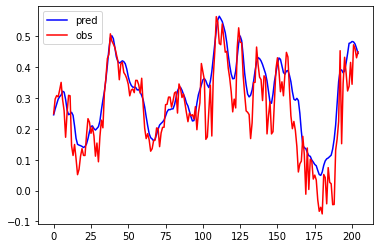

In [17]:
# plot actual and predictions
# i,j=25,35
i,j=10,10
plt.plot(predictions[:,look_forward-1,i,j],'blue')
plt.plot(y_test[:,look_forward-1,i,j],'red')
plt.legend(["pred", "obs"], loc ="upper left")
plt.show()

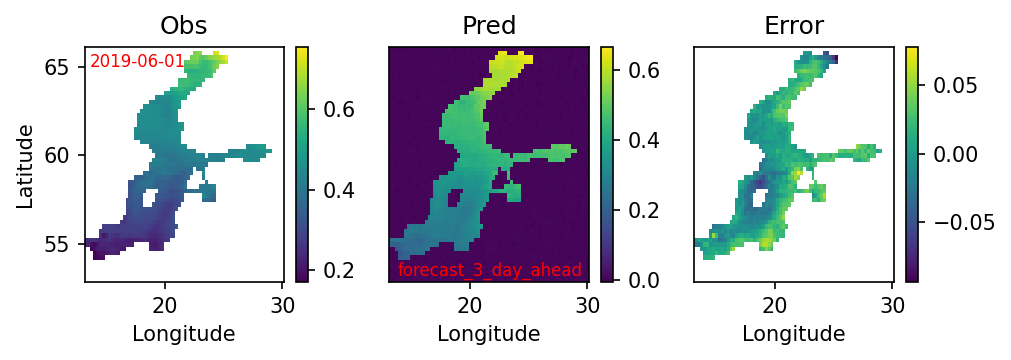

In [18]:
# from mpl_toolkits.basemap import Basemap
import matplotlib.pyplot as plt

day=0
# Create a datetime index between the start and end date
date_range = pd.date_range(start='2019-06-01', end='2019-12-22', freq='D')

# Convert the datetime index to a numpy array
date_array = np.array(date_range)
date=date_array[day]
# Print the resulting array
# print(date_array)
# Convert the numpy datetime64 object to a string in the format 'YYYY-MM-DD'
my_date = np.datetime_as_string(date, unit='D')

# rename to actual and pred
pred=predictions[day,look_forward-1,:,:]
actual=y_test[day,look_forward-1,:,:]

# get data matrix from mat file
lats = scipy.io.loadmat('lat_Poster.mat')
lat_names = scipy.io.whosmat('lat_Poster.mat')
lats = lats[lat_names[0][0]]
lons = scipy.io.loadmat('lon_Poster.mat')
lon_names = scipy.io.whosmat('lon_Poster.mat')
lons = lons[lon_names[0][0]]
# convert to numpy array
lats = np.array(lats)
lons = np.array(lons)

lats=lats.flatten()
lons=lons.flatten()

# Create a meshgrid of longitudes and latitudes
long_mesh, lat_mesh = np.meshgrid(lons, lats)

actual=actual.reshape(actual.shape[0],actual.shape[1])

# Convert all occurrences of 0 to NaN
pred = np.where(pred == 0, np.nan, pred)
actual = np.where(actual == 0, np.nan, actual)
error=pred-actual

# pred[pred < 0.1] = np.nan

# Create a figure with subplots
fig, axs = plt.subplots(1, 3, figsize=(7, 2.5), dpi=150)


# Plot the data in the first subplot
c0=axs[0].pcolormesh(long_mesh, lat_mesh, actual)
axs[0].set_title('Obs')
axs[0].text(13.6,65, my_date, fontsize=8, color='red')
cb0 = plt.colorbar(c0, ax=axs[0])
# axs[0].text(13.8,53.25, 'forecast_3_day_ahead', fontsize=8, color='red')
# cb0.set_clim(44,65)
# Plot the data in the second subplot
c1=axs[1].pcolormesh(long_mesh, lat_mesh, pred)
axs[1].set_title('Pred')
cb1 = plt.colorbar(c1, ax=axs[1])
axs[1].set_yticks([]) # turn off yticks for the second subplot
axs[1].text(13.8,53.25, 'forecast_3_day_ahead', fontsize=8, color='red')

# cb1.set_clim(44,65)
# Plot the data in the last subplot
c2=axs[2].pcolormesh(long_mesh, lat_mesh, error)
axs[2].set_title('Error')
cb2 = plt.colorbar(c2, ax=axs[2])
axs[2].set_yticks([]) # turn off yticks for the second subplot
# cb2.set_label('cm')
# cb2.set_clim(0.2,0.8)
# Set the y-axis labels for both subplots
axs[0].set_ylabel('Latitude')
axs[0].set_xlabel('Longitude')
axs[1].set_xlabel('Longitude')
# Set the x-axis label for the last subplot
axs[-1].set_xlabel('Longitude')

fig.tight_layout()
# Show the plots
plt.show()


In [ ]:
## save results
# result = np.concatenate((actual, pred, error), axis=0)
Baltic = np.concatenate((actual[:,:,np.newaxis], pred[:,:,np.newaxis], error[:,:,np.newaxis]), axis=2)
Baltic.shape

### Performance on average

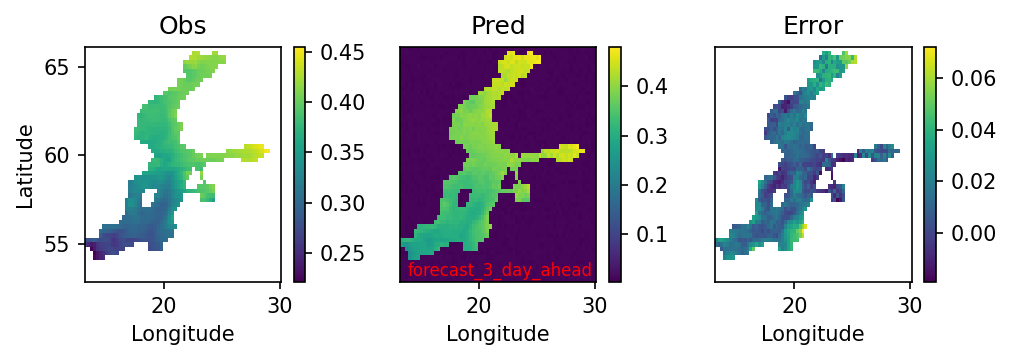

In [35]:
# from mpl_toolkits.basemap import Basemap
import matplotlib.pyplot as plt

# day=195
# Create a datetime index between the start and end date
date_range = pd.date_range(start='2019-06-01', end='2019-12-22', freq='D')

# rename to actual and pred
pred=predictions[:,look_forward-1,:,:]
actual=y_test[:,look_forward-1,:,:]
pred2= np.nanmean(pred, axis=0)
actual2= np.nanmean(actual,axis=0)
# get data matrix from mat file
lats = scipy.io.loadmat('lat_Poster.mat')
lat_names = scipy.io.whosmat('lat_Poster.mat')
lats = lats[lat_names[0][0]]
lons = scipy.io.loadmat('lon_Poster.mat')
lon_names = scipy.io.whosmat('lon_Poster.mat')
lons = lons[lon_names[0][0]]
# convert to numpy array
lats = np.array(lats)
lons = np.array(lons)

lats=lats.flatten()
lons=lons.flatten()

# Create a meshgrid of longitudes and latitudes
long_mesh, lat_mesh = np.meshgrid(lons, lats)

# actual2=actual2.reshape(actual.shape[0],actual.shape[1])

# Convert all occurrences of 0 to NaN
pred2 = np.where(pred2 == 0, np.nan, pred2)
actual2 = np.where(actual2 == 0, np.nan, actual2)
error2=pred2-actual2

pred2[pred2 < 0] = np.nan

# Create a figure with subplots
fig, axs = plt.subplots(1, 3, figsize=(7, 2.5), dpi=150)


# Plot the data in the first subplot
c0=axs[0].pcolormesh(long_mesh, lat_mesh, actual2)
axs[0].set_title('Obs')
# axs[0].text(13.6,65, my_date, fontsize=8, color='red')
cb0 = plt.colorbar(c0, ax=axs[0])
# axs[0].text(13.8,53.25, 'forecast_3_day_ahead', fontsize=8, color='red')
# cb0.set_clim(44,65)
# Plot the data in the second subplot
c1=axs[1].pcolormesh(long_mesh, lat_mesh, pred2)
axs[1].set_title('Pred')
cb1 = plt.colorbar(c1, ax=axs[1])
axs[1].set_yticks([]) # turn off yticks for the second subplot
axs[1].text(13.8,53.25, 'forecast_3_day_ahead', fontsize=8, color='red')

# cb1.set_clim(44,65)
# Plot the data in the last subplot
c2=axs[2].pcolormesh(long_mesh, lat_mesh, error2)
axs[2].set_title('Error')
cb2 = plt.colorbar(c2, ax=axs[2])
axs[2].set_yticks([]) # turn off yticks for the second subplot
# cb2.set_label('cm')
# cb2.set_clim(0.2,0.8)
# Set the y-axis labels for both subplots
axs[0].set_ylabel('Latitude')
axs[0].set_xlabel('Longitude')
axs[1].set_xlabel('Longitude')
# Set the x-axis label for the last subplot
axs[-1].set_xlabel('Longitude')

fig.tight_layout()
# Show the plots
plt.show()
# Export the plot as a PDF file